In [ ]:
# benchmark metric comparison
import pandas as pd
import seaborn as sn
from glob import glob
import pylab as plt
import numpy as np

import sys
sys.path.append('../')
import MHMDS.embed_funs as emb
import matplotlib.patches as mpatches

from plotly.colors import sample_colorscale, diverging

In [2]:
# plot parameters
plt.style.use('my_journal.mplstyle')
def clean_axis(ax=None):
    if ax is None:
        ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=3)

In [3]:
# 3d data not include ToggleSwitch, because it is only 2d

# if want to plot all 6 datasets:
dataset_names_2d = ['ToggleSwitch','Krumsiek11','Paul_PCA100','Olsson_PCA100',
                 'Celegans_10k_PCA100','Celegans_40k_PCA100']
dataset_names_3d = ['Krumsiek11','Paul_PCA100','Olsson_PCA100',
                 'Celegans_10k_PCA100','Celegans_40k_PCA100']

dataset_names_sel = ['Paul_PCA100','Celegans_40k_PCA100']

# if want to plot two datasets in the main figure
# dataset_names_2d = ['Paul_PCA100','Celegans_40k_PCA100']
# dataset_names_3d = ['Paul_PCA100','Celegans_40k_PCA100']

In [4]:
# load embedding metrics from competing method
phatelist_3d = [pd.read_csv('../Competing-Methods/phate/result/metrics_FeatMat_%s_nd_3.csv'%(name)
                         ,index_col=0) for name in dataset_names_3d]
phatelist_2d = [pd.read_csv('../Competing-Methods/phate/result/metrics_FeatMat_%s_nd_2.csv'%(name)
                         ,index_col=0) for name in dataset_names_2d]

In [5]:
scanpylist_2d = [pd.read_csv(glob('../Competing-Methods/scanpy/result/metrics_FeatMat_%s_nn_*_nd_2.csv'%(name))[0],
           index_col=0) for name in dataset_names_2d]

In [6]:
scanpylist_3d = [pd.read_csv(glob('../Competing-Methods/scanpy/result/metrics_FeatMat_%s_nn_*_nd_2.csv'%(name))[0],
           index_col=0).iloc[[0,2,3],:] for name in dataset_names_3d]
# method in scanpy: tsne and ForceAltlas only has 2d, so exclude them when loading 3d

In [7]:
# poincare map is only 2d
poincaremaplist = [pd.read_csv(glob('../Competing-Methods/poincaremap/result/metric_%s_*.csv'%(name))[0]) 
                   for name in dataset_names_2d]
for df in poincaremaplist:
    df['Method'] = 'PoincareMap'

In [8]:
# load data for tsne-3d
tsnelist_3d = [pd.read_csv(glob('../Competing-Methods/3dtsne/result/metric_%s_*.csv'%(name))[0]) 
                   for name in dataset_names_3d]
for df in tsnelist_3d:
    df['Method'] = 't-sne'

In [9]:
# load embedding metrics from mhmds - 3d
mhmdslist_3d = [pd.read_csv(glob('../MultiscalehMDS_feature/result/FeatMat_%s/benchmark/*Nd_3*metrics.csv'%(name))[0],
                        index_col=0).iloc[:,:4] for name in dataset_names_3d]
for i,df in enumerate(mhmdslist_3d):
    if pd.isna(df.iloc[-2,1]):
        mhmdslist_3d[i] = df.iloc[1:2,:]
    else:
        mhmdslist_3d[i] = df.iloc[2:3,:]
    mhmdslist_3d[i]['Step'] = 'MuH-MDS'
    mhmdslist_3d[i].rename({'Step':'Method','corr':'Corr'},axis=1,inplace=True)

/var/folders/x4/m6sn1g5s4yjb6ybj1mpz8c600000gn/T/ipykernel_34938/2265429347.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mhmdslist_3d[i]['Step'] = 'MuH-MDS'
/var/folders/x4/m6sn1g5s4yjb6ybj1mpz8c600000gn/T/ipykernel_34938/2265429347.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mhmdslist_3d[i].rename({'Step':'Method','corr':'Corr'},axis=1,inplace=True)


In [12]:
# load embedding metrics from mhmds - 2d
mhmdslist_2d = [pd.read_csv(glob('../MultiscalehMDS_feature/result/FeatMat_%s/benchmark/*Nd_2*metrics.csv'%(name))[0],
                        index_col=0).iloc[:,:4] for name in dataset_names_2d]
for i,df in enumerate(mhmdslist_2d):
    if pd.isna(df.iloc[-2,1]):
        mhmdslist_2d[i] = df.iloc[1:2,:]
    else:
        mhmdslist_2d[i] = df.iloc[2:3,:]
    mhmdslist_2d[i]['Step'] = 'MuH-MDS'
    mhmdslist_2d[i].rename({'Step':'Method','corr':'Corr'},axis=1,inplace=True)

/var/folders/x4/m6sn1g5s4yjb6ybj1mpz8c600000gn/T/ipykernel_34938/3055738971.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mhmdslist_2d[i]['Step'] = 'MuH-MDS'
/var/folders/x4/m6sn1g5s4yjb6ybj1mpz8c600000gn/T/ipykernel_34938/3055738971.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mhmdslist_2d[i].rename({'Step':'Method','corr':'Corr'},axis=1,inplace=True)


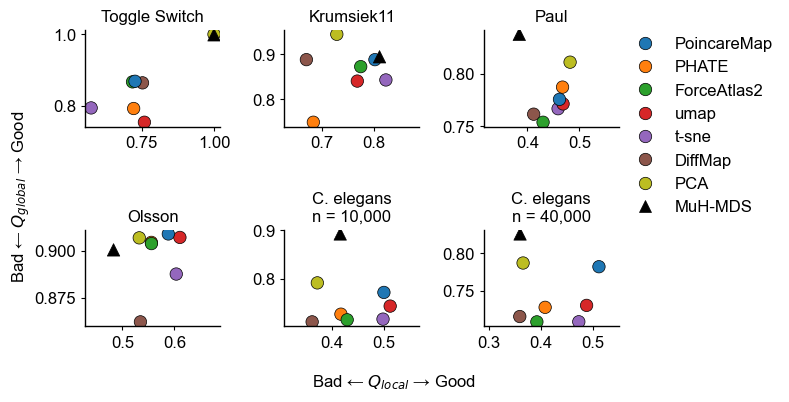

In [ ]:
# plot each: 2d
palette ={"PoincareMap": "C0", "PHATE": "C1", "ForceAtlas2": "C2", 
          'umap':'C3','t-sne':'C4','DiffMap':'C5','PCA':'C8','MuH-MDS':'k'}
markers = {"PoincareMap": "o", "PHATE": "o", "ForceAtlas2": "o", 
          'umap':'o','t-sne':'o','DiffMap':'o','SIMLR':'o',
          'SAUCIE':'o','PCA':'o','MuH-MDS':'^'}
namemaps = {'ToggleSwitch':'Toggle Switch',
            'Krumsiek11':'Krumsiek11',
            'Paul_PCA100':'Paul',
            'Olsson_PCA100':'Olsson',
            'Celegans_10k_PCA100':'C. elegans\nn = 10,000',
            'Celegans_40k_PCA100':'C. elegans\nn = 40,000'}
fig,axs = plt.subplots(2,3,figsize=(8,4))
axs = axs.flatten()
for i in range(len(dataset_names_2d)):
#     df_toplot = pd.concat([phatelist[i],scanpylist[i],mhmdslist[i]],axis=0)
    df_toplot = pd.concat([phatelist_2d[i],scanpylist_2d[i],poincaremaplist[i],mhmdslist_2d[i]],axis=0)
    sn.scatterplot(data=df_toplot,ax=axs[i],x='Qlocal',y='Qglobal',
                   hue='Method',s=80,palette=palette, style = 'Method',markers=markers,
                   linewidth=0.5,edgecolor='k',hue_order = palette)
    axs[i].set_title(namemaps[dataset_names_2d[i]],fontsize=12)
    axs[i].set_xlabel('')
    axs[i].set_ylabel('')
    axs[i].tick_params(axis="x", labelsize=12)  
    axs[i].tick_params(axis="y", labelsize=12)
    
#     plt.xlabel('Correlation',fontsize=15)
    
    axs[i].legend([],[], frameon=False)
#     plt.axis('equal')
    if i!= 0:
        axs[i].set_xlim([np.mean(df_toplot.Qlocal)-0.13,np.mean(df_toplot.Qlocal)+0.13])
#     axs[i].set_ylim([0,1])
    clean_axis(ax=axs[i])
axs[2].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,fontsize=12)
fig.supylabel('Bad ← $Q_{global}$ → Good',fontsize=12)
fig.supxlabel('Bad ← $Q_{local}$ → Good',fontsize=12)

plt.tight_layout()
# plt.savefig('Qs_2d_all.svg',format='svg',transparent=True)

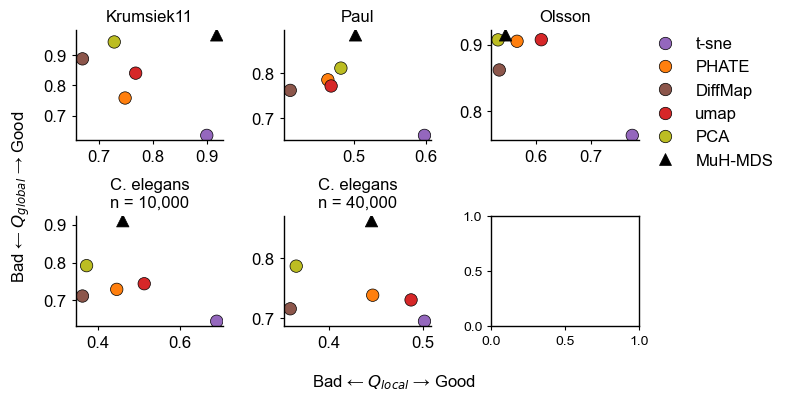

In [ ]:
# plot each: 3d
fig,axs = plt.subplots(2,3,figsize=(8,4))
axs = axs.flatten()
for i in range(len(dataset_names_3d)):
#     df_toplot = pd.concat([phatelist[i],scanpylist[i],mhmdslist[i]],axis=0)
    df_toplot = pd.concat([tsnelist_3d[i],phatelist_3d[i],scanpylist_3d[i],mhmdslist_3d[i]],axis=0)
    sn.scatterplot(data=df_toplot,ax=axs[i],x='Qlocal',y='Qglobal',hue='Method',
                   s=80,palette=palette, style = 'Method',markers=markers,
                   linewidth=0.5,edgecolor='k')
    axs[i].set_title(namemaps[dataset_names_3d[i]],fontsize=12)
    axs[i].set_xlabel('')
    axs[i].set_ylabel('')
    axs[i].tick_params(axis="x", labelsize=12)  
    axs[i].tick_params(axis="y", labelsize=12)
    
#     plt.xlabel('Correlation',fontsize=15)
    
    axs[i].legend([],[], frameon=False)
#     plt.axis('equal')
    if i!= 0:
        pass
    clean_axis(ax=axs[i])
axs[2].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,fontsize=12)
fig.supylabel('Bad ← $Q_{global}$ → Good',fontsize=12)
fig.supxlabel('Bad ← $Q_{local}$ → Good',fontsize=12)

plt.tight_layout()
# plt.savefig('Qs_3d_all.svg',format='svg',transparent=True)

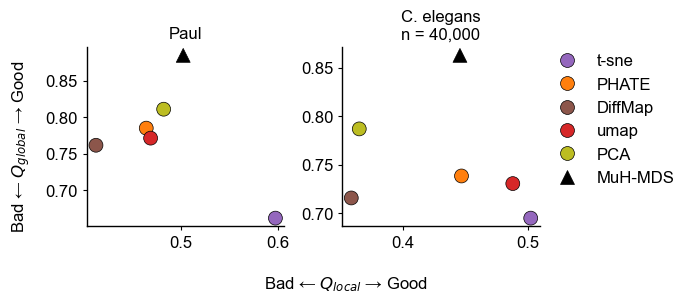

In [ ]:
# plot each: 3d
fig,axs = plt.subplots(1,2,figsize=(7,3))
axs = axs.flatten()
# find index of dataset_names_sel in dataset_names_3d
idx_ = [dataset_names_3d.index(name) for name in dataset_names_sel]

for i in range(len(dataset_names_sel)):
    df_toplot = pd.concat([tsnelist_3d[idx_[i]],phatelist_3d[idx_[i]],scanpylist_3d[idx_[i]],mhmdslist_3d[idx_[i]]],axis=0)
    sn.scatterplot(data=df_toplot,ax=axs[i],x='Qlocal',y='Qglobal',hue='Method',
                   s=100,palette=palette, style = 'Method',markers=markers,
                   linewidth=0.5,edgecolor='k')
    axs[i].set_title(namemaps[dataset_names_sel[i]],fontsize=12)
    axs[i].set_xlabel('')
    axs[i].set_ylabel('')
    axs[i].tick_params(axis="x", labelsize=12)  
    axs[i].tick_params(axis="y", labelsize=12)
    
    
    axs[i].legend([],[], frameon=False)
    if i!= 0:
        pass
    clean_axis(ax=axs[i])
axs[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,fontsize=12)
fig.supylabel('Bad ← $Q_{global}$ → Good',fontsize=12)
fig.supxlabel('Bad ← $Q_{local}$ → Good',fontsize=12)

plt.tight_layout()
# plt.savefig('Qs_3d_only2.svg',format='svg',transparent=True)

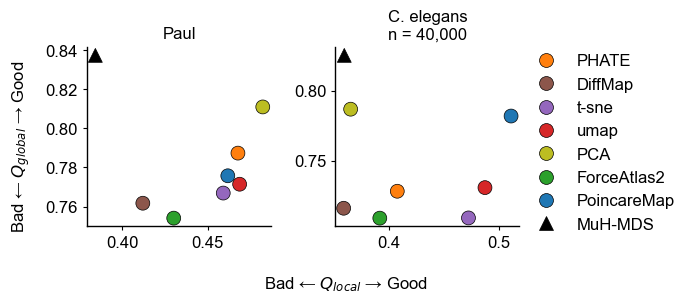

In [ ]:
# plot each: 2d, only 2
fig,axs = plt.subplots(1,2,figsize=(7,3))
axs = axs.flatten()
# find index of dataset_names_sel in dataset_names_2d
idx_ = [dataset_names_2d.index(name) for name in dataset_names_sel]
for i in range(len(dataset_names_sel)):
    df_toplot = pd.concat([phatelist_2d[idx_[i]],scanpylist_2d[idx_[i]],poincaremaplist[idx_[i]],
                           mhmdslist_2d[idx_[i]]],axis=0)
    sn.scatterplot(data=df_toplot,ax=axs[i],x='Qlocal',y='Qglobal',hue='Method',
                   s=100,palette=palette, style = 'Method',markers=markers,
                   linewidth=0.5,edgecolor='k')
    axs[i].set_title(namemaps[dataset_names_sel[i]],fontsize=12)
    axs[i].set_xlabel('')
    axs[i].set_ylabel('')
    axs[i].tick_params(axis="x", labelsize=12)  
    axs[i].tick_params(axis="y", labelsize=12)
    
    axs[i].legend([],[], frameon=False)
#     plt.axis('equal')
    if i!= 0:
        pass
    clean_axis(ax=axs[i])
axs[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,fontsize=12)
fig.supylabel('Bad ← $Q_{global}$ → Good',fontsize=12)
fig.supxlabel('Bad ← $Q_{local}$ → Good',fontsize=12)

plt.tight_layout()
# plt.savefig('Qs_2d_only2.svg',format='svg',transparent=True)


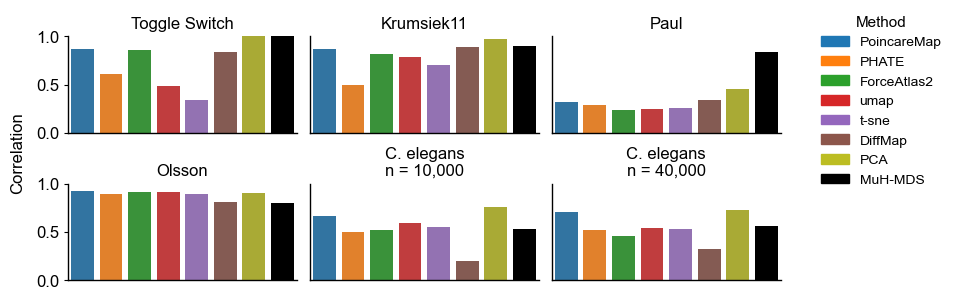

In [ ]:
# correlation - 2d
fig,axs = plt.subplots(2,3,figsize=(8,3))
axs = axs.flatten()
for i in range(len(dataset_names_2d)):
    df_toplot = pd.concat([phatelist_2d[i],scanpylist_2d[i],poincaremaplist[i],mhmdslist_2d[i]],axis=0)
    sn.barplot(data=df_toplot,x='Method',y='Corr',hue='Method',palette=palette,order = palette, hue_order= palette,
               ax=axs[i])
    axs[i].set_title(namemaps[dataset_names_2d[i]],fontsize=12)
    axs[i].set_ylabel(None)
    # remove x label and ticks
    axs[i].tick_params(axis="y", labelsize=12)
    axs[i].set_xlabel(None)
    axs[i].set_xticks([])
    clean_axis(ax=axs[i])
    axs[i].set_ylim([0,1])
    if i != 0 and i != 3:
        axs[i].set_yticks([])
    # axs[i].legend()
fig.supylabel('Correlation',fontsize=12)


handles = [mpatches.Patch(color=palette[method], label=method) for method in palette]

fig.legend(handles=handles, title='Method', loc='upper right', bbox_to_anchor=(1.2, 1), fontsize=10, title_fontsize=11, frameon=False)
plt.tight_layout()
# plt.savefig('corrs_2d_all.svg',format='svg',transparent=True)

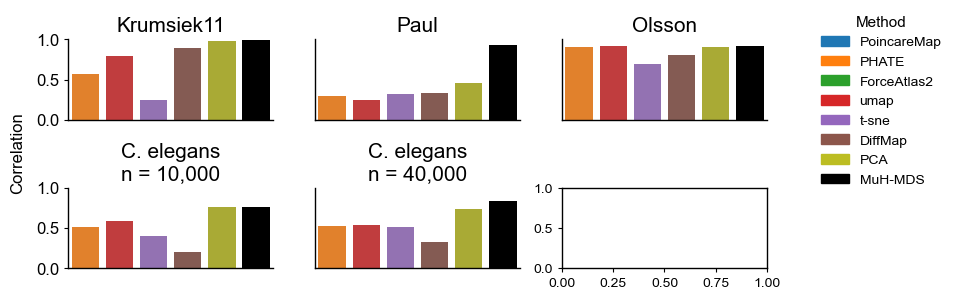

In [ ]:
# correlation - 3d
fig,axs = plt.subplots(2,3,figsize=(8,3))
axs = axs.flatten()
ord_ = ['PHATE','umap','t-sne','DiffMap','PCA','MuH-MDS']
for i in range(len(dataset_names_3d)):
    df_toplot = pd.concat([tsnelist_3d[i],phatelist_3d[i],scanpylist_3d[i],mhmdslist_3d[i]],axis=0)
    sn.barplot(data=df_toplot,x='Method',y='Corr',hue='Method',order = ord_, hue_order= ord_,
               palette=palette,ax=axs[i])
    axs[i].set_title(namemaps[dataset_names_3d[i]],fontsize=15)
    axs[i].set_ylabel(None)
    # remove x label and ticks
    axs[i].tick_params(axis="y", labelsize=12)
    axs[i].set_xlabel(None)
    axs[i].set_xticks([])
    clean_axis(ax=axs[i])
    axs[i].set_ylim([0,1])
    if i != 0 and i != 3:
        axs[i].set_yticks([])
fig.supylabel('Correlation',fontsize=12)

handles = [mpatches.Patch(color=palette[method], label=method) for method in palette]

fig.legend(handles=handles, title='Method', loc='upper right', bbox_to_anchor=(1.2, 1), fontsize=10, title_fontsize=11, frameon=False)
plt.tight_layout()
# plt.savefig('corrs_3d_all.svg',format='svg',transparent=True)

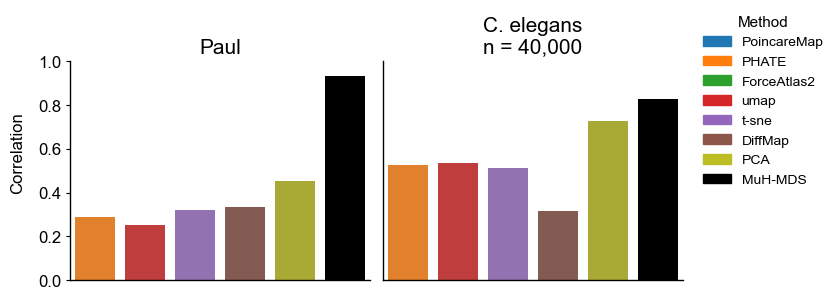

In [ ]:
# correlation - 3d

fig,axs = plt.subplots(1,2,figsize=(7,3))
axs = axs.flatten()
# find index of dataset_names_sel in dataset_names_3d
idx_ = [dataset_names_3d.index(name) for name in dataset_names_sel]
for i in range(len(dataset_names_sel)):
    df_toplot = pd.concat([tsnelist_3d[idx_[i]],phatelist_3d[idx_[i]],scanpylist_3d[idx_[i]],mhmdslist_3d[idx_[i]]],axis=0)
    sn.barplot(data=df_toplot,x='Method',y='Corr',hue='Method',order = ord_, hue_order= ord_,
               palette=palette,
               ax=axs[i])
    axs[i].set_title(namemaps[dataset_names_sel[i]],fontsize=15)
    axs[i].set_ylabel(None)
    # remove x label and ticks
    axs[i].tick_params(axis="y", labelsize=12)
    axs[i].set_xlabel(None)
    axs[i].set_xticks([])
    clean_axis(ax=axs[i])
    axs[i].set_ylim([0,1])
    if i != 0:
        axs[i].set_yticks([])
    
fig.supylabel('Correlation',fontsize=12)
handles = [mpatches.Patch(color=palette[method], label=method) for method in palette]

fig.legend(handles=handles, title='Method', loc='upper right', bbox_to_anchor=(1.2, 1), fontsize=10, title_fontsize=11, frameon=False)
plt.tight_layout()
# plt.savefig('corrs_3d_only2.svg',format='svg',transparent=True)

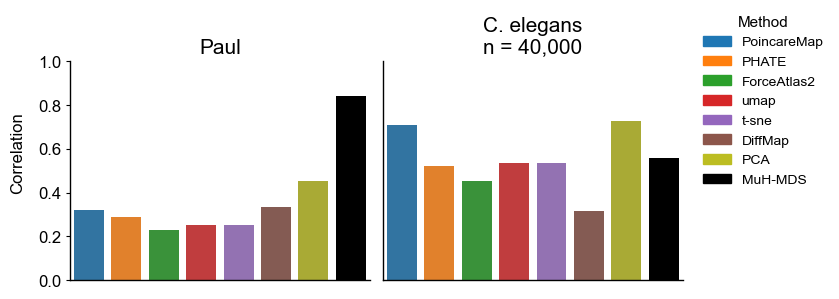

In [ ]:
# correlation - 2d

fig,axs = plt.subplots(1,2,figsize=(7,3))
axs = axs.flatten()
# find index of dataset_names_sel in dataset_names_2d
idx_ = [dataset_names_2d.index(name) for name in dataset_names_sel]
for i in range(len(dataset_names_sel)):
    df_toplot = pd.concat([phatelist_2d[idx_[i]],scanpylist_2d[idx_[i]],
                           poincaremaplist[idx_[i]],mhmdslist_2d[idx_[i]]],axis=0)
    sn.barplot(data=df_toplot,x='Method',y='Corr',hue='Method',order = palette, hue_order= palette,
               palette=palette,ax=axs[i])
    axs[i].set_title(namemaps[dataset_names_sel[i]],fontsize=15)
    axs[i].set_ylabel(None)
    # remove x label and ticks
    axs[i].tick_params(axis="y", labelsize=12)
    axs[i].set_xlabel(None)
    axs[i].set_xticks([])
    clean_axis(ax=axs[i])
    axs[i].set_ylim([0,1])
    if i != 0:
        axs[i].set_yticks([])
    
fig.supylabel('Correlation',fontsize=12)
handles = [mpatches.Patch(color=palette[method], label=method) for method in palette]
fig.legend(handles=handles, title='Method', loc='upper right', bbox_to_anchor=(1.2, 1), fontsize=10, title_fontsize=11, frameon=False)
plt.tight_layout()
# plt.savefig('corrs_2d_only2.svg',format='svg',transparent=True)

In [22]:
# visualize C elegans data 40k
# metadata
metadata = pd.read_csv('../data/metadata/Celegans_40k_PCA100_metadata.csv',index_col=0)
metadata.head()
metadata['cell.type'][pd.isna(metadata['cell.type'])]='Unannotated'

/var/folders/x4/m6sn1g5s4yjb6ybj1mpz8c600000gn/T/ipykernel_34938/3325316908.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metadata['cell.type'][pd.isna(metadata['cell.type'])]='Unannotated'


In [23]:
# poincare map
poincoords = pd.read_csv('../Competing-Methods/poincaremap/result/Celegans_40k_PCA100_PM30sigma=2.00gamma=1.00minkowskipca=0_seed0.csv',header=None)
poincoords.head()

,0,1
0,0.622075,0.270626
1,-0.047739,-0.707607
2,-0.446167,0.889806
3,0.727966,-0.374266
4,-0.466357,0.783170


In [24]:
# mhmds
coords = np.loadtxt('../MultiscalehMDS_feature/result/FeatMat_Celegans_40k_PCA100/benchmark/cls_200_Nn_30_Nd_2_min_3_max_500_coords_40000.txt')
inds = np.loadtxt('../MultiscalehMDS_feature/result/FeatMat_Celegans_40k_PCA100/benchmark/cls_200_Nn_30_Nd_2_min_3_max_500_inds_after_prep.txt')
coords = coords[np.argsort(inds)]

In [ ]:
# recenter

datarc = emb.perform_recenter(coords,np.arange(40000))
datarc_poin = emb.perform_recenter(np.array(poincoords),np.arange(40000))

23:00:15 - cmdstanpy - INFO - Chain [1] start processing
23:00:15 - cmdstanpy - INFO - Chain [1] done processing
23:00:16 - cmdstanpy - INFO - Chain [1] start processing
23:00:16 - cmdstanpy - INFO - Chain [1] done processing


/var/folders/x4/m6sn1g5s4yjb6ybj1mpz8c600000gn/T/ipykernel_34938/1494063978.py:20: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  plt.colorbar(sm).set_label(label='Embryo Time (mins)',size=15)


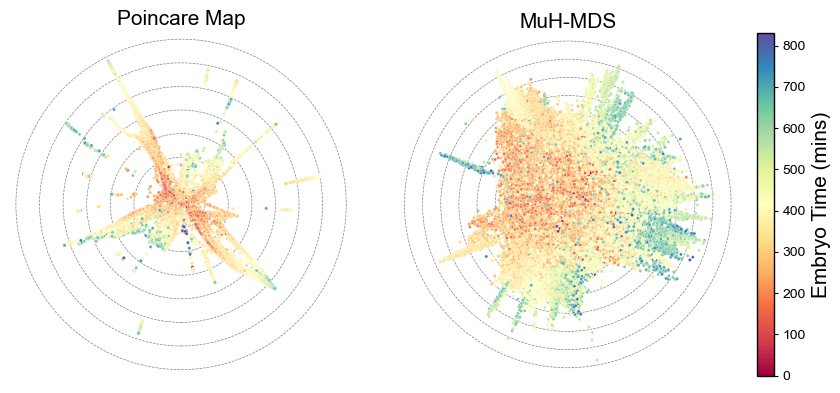

In [ ]:

df_pm = pd.concat([metadata.reset_index(),pd.DataFrame(emb.to_native(datarc_poin))],axis=1)
df_mhmds = pd.concat([metadata.reset_index(),pd.DataFrame(emb.to_native(datarc))],axis=1)
fig, axs = plt.subplots(1,2,figsize=(9,4))
sn.scatterplot(data=df_pm, x=0,y=1,hue='embryo.time',palette = 'Spectral',ax=axs[0],s=5)

sn.scatterplot(data=df_mhmds, x=0,y=1,hue='embryo.time',palette = 'Spectral',ax=axs[1],s=5)

norm = plt.Normalize(df_pm['embryo.time'].min(), df_pm['embryo.time'].max())
sm = plt.cm.ScalarMappable(cmap="Spectral", norm=norm)
sm.set_array([])

# Remove the legend and add a colorbar
axs[0].get_legend().remove()
axs[1].get_legend().remove()
plt.colorbar(sm).set_label(label='Embryo Time (mins)',size=15)


# plot circle and remove axis

axs[0].set_title('Poincare Map', fontsize=15)
axs[1].set_title('MuH-MDS', fontsize=15)

dfs = [df_pm, df_mhmds]
for i in range(2):
    maxradius = np.ceil(np.max(np.sqrt(dfs[i][0]**2 + dfs[i][1]**2)))
    rads = np.arange(1,maxradius + 1, 1)
    for r in rads:
        circle = plt.Circle((0, 0), r, color='gray', fill=False, linestyle='--', linewidth=0.5,zorder = 0)
        axs[i].add_artist(circle)
    axs[i].tick_params(axis="x", labelsize=12)  
    axs[i].tick_params(axis="y", labelsize=12)
    axs[i].set_aspect('equal', adjustable='box')
    axs[i].set_xlim(-rads[-1]-0.25, rads[-1]+0.25)
    axs[i].set_ylim(-rads[-1]-0.25, rads[-1]+0.25)
    axs[i].set_axis_off()
    # set aspect ratio to equal
    axs[i].set_aspect('equal', adjustable='box')

plt.tight_layout()

In [27]:
# cell types: regroup
toplot = metadata.groupby('cell.type').count().iloc[:,1].sort_values(ascending=False)[:15].index

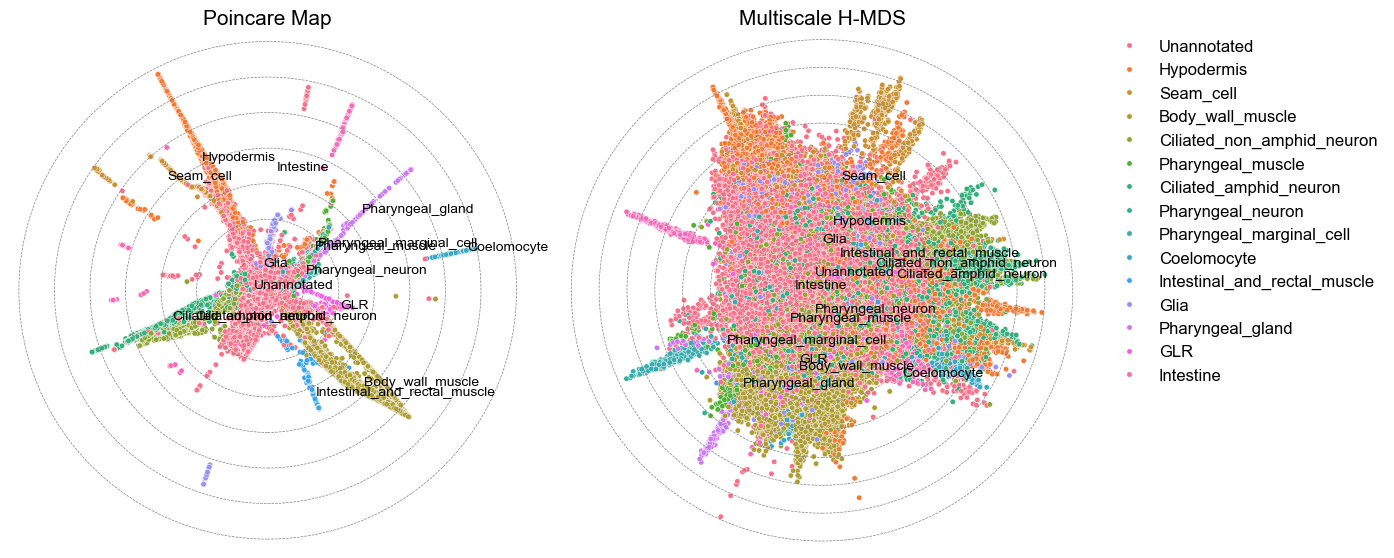

In [ ]:
fig, axs = plt.subplots(1,2,figsize=(14,7))
axs = axs.flatten()
sn.scatterplot(data=df_pm[np.isin(df_pm['cell.type'],toplot)], x=0,y=1,hue='cell.type',ax=axs[0],s=15)
sn.scatterplot(data=df_mhmds[np.isin(df_pm['cell.type'],toplot)], x=0,y=1,hue='cell.type',ax=axs[1],s=15)
axs[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0,fontsize=12,ncols=1)

# Remove the legend and add a colorbar
axs[0].get_legend().remove()

for types in toplot:
    axs[0].annotate(types, xy = np.mean(df_pm[df_pm['cell.type']==types][[0,1]],axis=0),fontsize=10)
for types in toplot:
    axs[1].annotate(types, xy = np.mean(df_mhmds[df_mhmds['cell.type']==types][[0,1]],axis=0),fontsize=10)
    
axs[0].set_xlabel('Poincare Map - 1', fontsize=15)
axs[0].set_ylabel('Poincare Map - 2', fontsize=15)

axs[1].set_xlabel('Multiscale H-MDS - 1', fontsize=15)
axs[1].set_ylabel('Multiscale H-MDS - 2', fontsize=15)

axs[0].set_title('Poincare Map', fontsize=15)
axs[1].set_title('Multiscale H-MDS', fontsize=15)


for i in range(2):

    maxradius = np.ceil(np.max(np.sqrt(dfs[i][0]**2 + dfs[i][1]**2)))
    rads = np.arange(1,maxradius + 1, 1)
    for r in rads:
        circle = plt.Circle((0, 0), r, color='gray', fill=False, linestyle='--', linewidth=0.5)
        axs[i].add_artist(circle)
    axs[i].tick_params(axis="x", labelsize=12)  
    axs[i].tick_params(axis="y", labelsize=12)
    axs[i].set_aspect('equal', adjustable='box')
    axs[i].set_xlim(-rads[-1]-0.25, rads[-1]+0.25)
    axs[i].set_ylim(-rads[-1]-0.25, rads[-1]+0.25)
    axs[i].set_axis_off()
    # set aspect ratio to equal
    axs[i].set_aspect('equal', adjustable='box')


plt.tight_layout()

In [ ]:

df_pm['radii'] = np.linalg.norm(emb.to_native(datarc_poin),axis=1)

df_mhmds['radii'] = np.linalg.norm(emb.to_native(datarc),axis=1)


In [30]:
lplot = ['< 100','100-130','130-170','170-210','210-270','270-330','330-390',
         '390-450','450-510','510-580','580-650','> 650']
xx = []
mean_poin = []
mean_mhmds = []
for ind in lplot[:-1]:
    mean_poin.append(np.mean(df_pm[df_pm['embryo.time.bin'] == ind]['radii']))
    mean_mhmds.append(np.mean(df_mhmds[df_mhmds['embryo.time.bin'] == ind]['radii']))
    xx.append(np.mean(df_pm[df_pm['embryo.time.bin'] == ind]['embryo.time']))

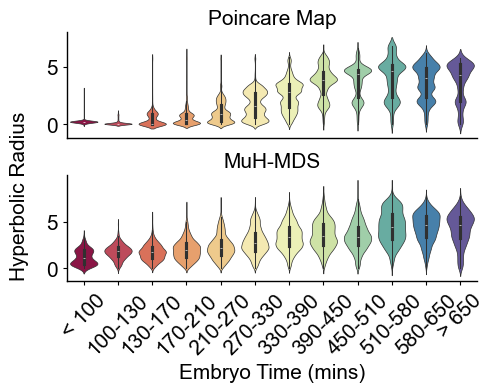

In [ ]:
# radius versus embryotime

def rgb_str_to_tuple(rgb_str):
    # e.g., 'rgb(94, 79, 162)' → (0.37, 0.31, 0.64)
    rgb = rgb_str.strip('rgb()').split(',')
    return tuple(int(x) / 255 for x in rgb)



num_colors = 12
spectral_12 = sample_colorscale(diverging.Spectral, [i / (num_colors - 1) for i in range(num_colors)])
spectral_12_tuple = [rgb_str_to_tuple(c) for c in spectral_12]
hue_values = lplot  # ensure order matches plot
palette_dict = dict(zip(hue_values, spectral_12_tuple))

fig,axs = plt.subplots(2,1,figsize = (5,4))
axs = axs.flatten()
sn.violinplot(data=df_pm[np.isin(df_pm['embryo.time.bin'], lplot)],x='embryo.time.bin',
              y='radii',order=lplot,hue='embryo.time.bin',ax = axs[0],linewidth=0.5,
              palette=palette_dict,)

sn.violinplot(data=df_mhmds[np.isin(df_mhmds['embryo.time.bin'], lplot)],x='embryo.time.bin',
              y='radii',order=lplot,hue='embryo.time.bin',ax = axs[1],linewidth=0.5,
              palette=palette_dict,)
for i in range(2):
    axs[i].set_ylabel('',fontsize=15)
    axs[i].tick_params(axis="y", labelsize=15)
    clean_axis(ax=axs[i])

axs[1].set_xlabel('Embryo Time (mins)',fontsize=15)

axs[1].tick_params(axis="x", labelsize=15,rotation=45)  
axs[0].tick_params(axis='x',labelbottom=False,bottom=False)
axs[0].set_xlabel('',fontsize=15)

axs[0].set_title('Poincare Map', fontsize=15)
    
axs[1].set_title('MuH-MDS', fontsize=15)

fig.supylabel('Hyperbolic Radius', fontsize=15)
    

plt.tight_layout()